In [32]:
from langgraph.graph import StateGraph,START,END
from typing import Annotated,TypedDict
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage

In [8]:
!pip install langchain-huggingface

from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    provider="nscale",
    huggingfacehub_api_token=HF_API_KEY,
    max_new_tokens=512,
)

model = ChatHuggingFace(llm=llm)

result = model.invoke("what is the capital of india")
print(result.content)

The capital of India is New Delhi.


In [10]:
class ChatState(TypedDict):
    message: Annotated[list[BaseMessage],add_messages]

In [56]:
def chat_node(state:ChatState):
  decision = interrupt({
      'type':'approval',
      'reason':'model is about to answer a user question',
      'question':state['message'][-1].content,
      'instruction':'Approve this question? YES/NO'
  })

  if decision['approved'] == 'no':
    return {'message':[AIMessage(content='NOT approved')]}
  else:
    response = model.invoke(state['message'])
    return {'message':[response]}

In [57]:
builder = StateGraph(ChatState)

builder.add_node("chat_node",chat_node)
builder.add_edge(START,'chat_node')
builder.add_edge('chat_node',END)

checkpointer = MemorySaver()

app  = builder.compile(checkpointer=checkpointer)

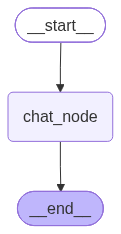

In [15]:
app

In [69]:
from langchain_core.messages import HumanMessage

config = {'configurable':{"thread_id":'1221'}}

initial_input={
    'message':[
        HumanMessage(content='explain gradient descent in very simple terms.')
    ]
}
result = app.invoke(initial_input,config=config)

In [59]:
result

{'message': [HumanMessage(content='explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='4dbc2957-f294-4302-9169-48232ea3bba0')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'model is about to answer a user question', 'question': 'explain gradient descent in very simple terms.', 'instruction': 'Approve this question? YES/NO'}, id='19c08131416fb5dc980a2d8518df3ab6')]}

In [70]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'model is about to answer a user question',
 'question': 'explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? YES/NO'}

In [71]:
user_input = input(f'\nBackend message -{message}\n Approve this question? (y/n): ')


Backend message -{'type': 'approval', 'reason': 'model is about to answer a user question', 'question': 'explain gradient descent in very simple terms.', 'instruction': 'Approve this question? YES/NO'}
 Approve this question? (y/n): no


In [72]:
final_result = app.invoke(
    Command(resume={'approved':user_input}),
    config=config
)

In [73]:
print(final_result['message'][-1].content)

NOT approved
